#### Import libraries.

In [1]:

import gc
import cv2
import math
import time
import tensorflow as tf
import numpy as np
from glob import glob
from tensorflow import keras
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Activation, BatchNormalization, Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split


#### Auxiliary function to load all images from disk into the data structures that will be used as inputs for the CNN.

In [2]:

images_height = 0
images_width = 0

def load_dataset():
    # Load all dataset images.
    # Returns:
    #    X_array (list): images list.
    #    y_array (list): images classification to be used as target.
    print("\nStart loading all images...")
    normal_images = [cv2.imread(nr_file, cv2.IMREAD_GRAYSCALE) for nr_file in glob("../dataset/resized_normal/*.png")]
    stone_images = [cv2.imread(st_file, cv2.IMREAD_GRAYSCALE) for st_file in glob("../dataset/resized_stone/*.png")]
    X_array = []
    y_array = []
    for nr_img in normal_images:
        X_array.append(nr_img)
        y_array.append(NORMAL_CLASS_VALUE)
    for st_img in stone_images:
        X_array.append(st_img)
        y_array.append(STONE_CLASS_VALUE)
    print("{} images loaded for normal classification.".format(len(normal_images)))
    print("{} images loaded for stone classification.".format(len(stone_images)))
    if len(X_array) > 0:
        global images_height
        global images_width
        images_height = X_array[0].shape[0]
        images_width = X_array[0].shape[1]
    print("\nFinish loading all images...")
    return X_array, y_array


#### Load dataset images for training.


Start loading all images...
750 images loaded for normal classification.
750 images loaded for stone classification.

Finish loading all images...

Show some images to illustrate the pattern.


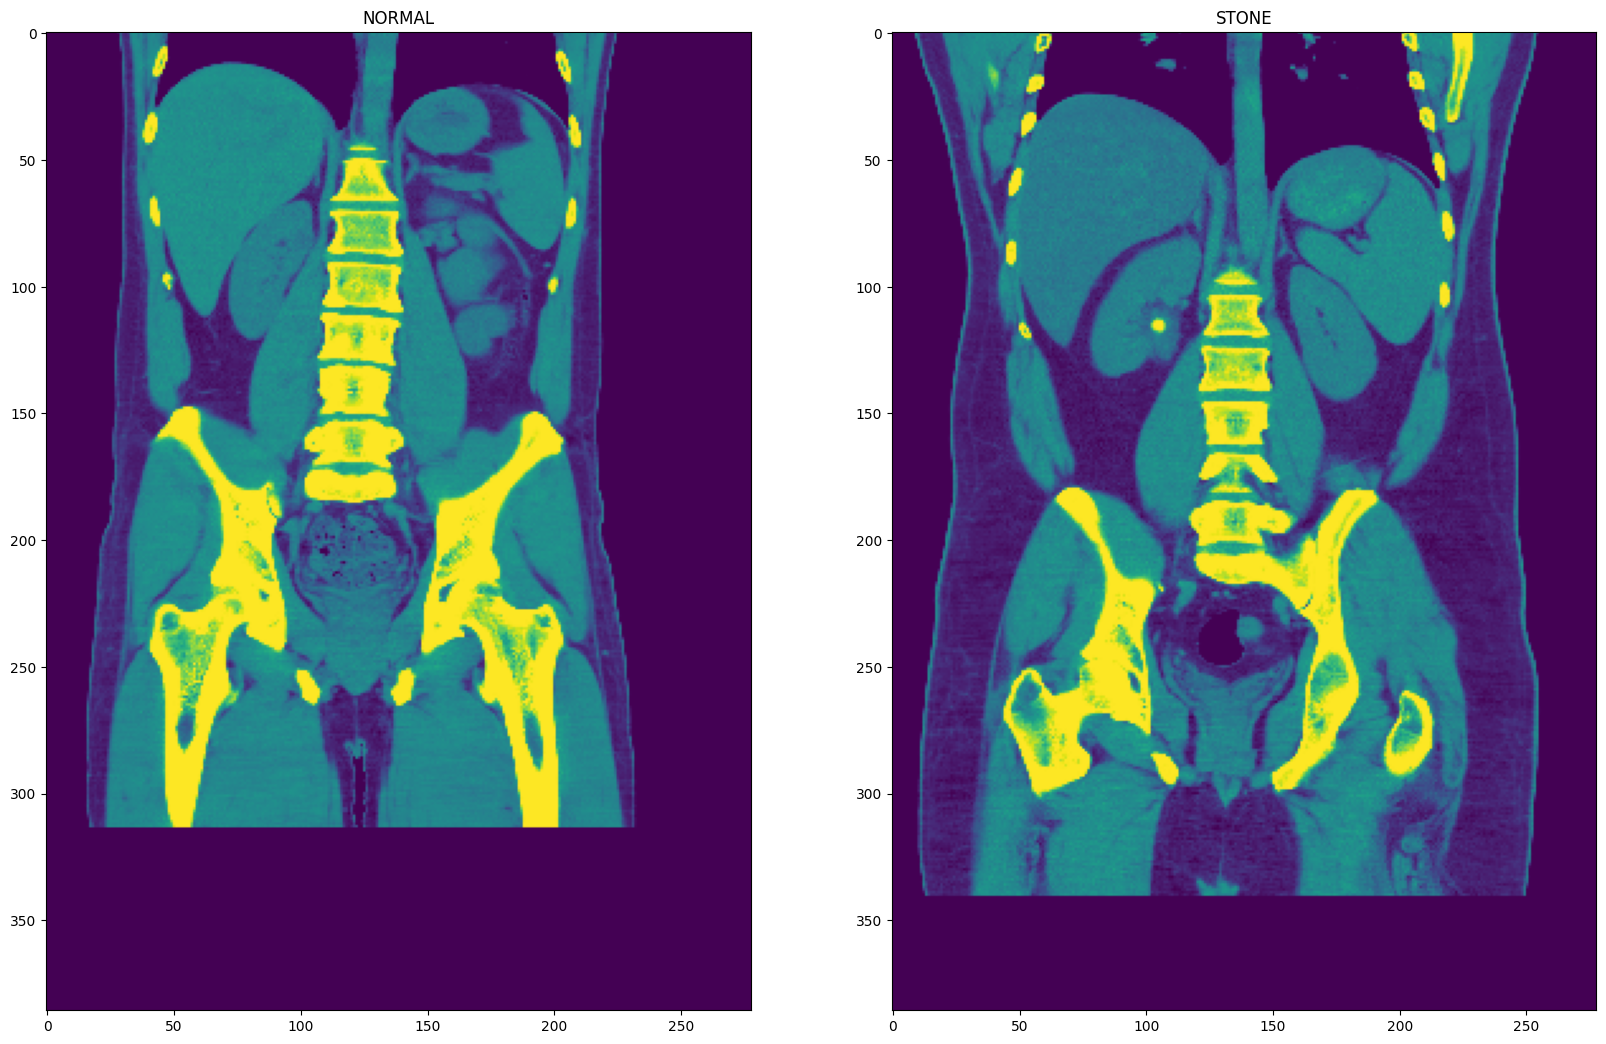

In [3]:

NORMAL_CLASS_VALUE = 0
STONE_CLASS_VALUE = 1

X_samples, y_samples = load_dataset()

if len(X_samples) > 0:
    # Show one image of each class to illustrate the pattern.
    print("\nShow some images to illustrate the pattern.")
    fig, aux = plt.subplots(1, 2, figsize = (20, 20))
    aux[0].set_title("NORMAL")
    aux[1].set_title("STONE")
    aux[0].imshow(X_samples[[i for i in range(len(X_samples)) if y_samples[i] == NORMAL_CLASS_VALUE][0]])
    aux[1].imshow(X_samples[[i for i in range(len(X_samples)) if y_samples[i] == STONE_CLASS_VALUE][0]])


#### Functions to create CNN architectures and train the created models.

In [4]:

def create_baseline():
    act_fuction = "relu"
    k_init = "he_uniform"
    model = Sequential()
    model.add(Conv2D(16, kernel_size = 3, input_shape = (images_height, images_width, 1)))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Conv2D(32, kernel_size = 3))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Conv2D(64, kernel_size = 3))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Flatten())
    model.add(Dense(32, activation = act_fuction, kernel_initializer = k_init))
    model.add(BatchNormalization())
    model.add(Dense(1, activation = 'sigmoid'))
    opt = Adam(learning_rate = 0.001)
    model.summary()
    model.compile(loss = "binary_crossentropy", optimizer = opt, metrics = ["accuracy"])
    return model

def create_v1():
    act_fuction = "relu"
    k_init = "he_uniform"
    model = Sequential()
    model.add(Conv2D(64, kernel_size = 3, input_shape = (images_height, images_width, 1)))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Conv2D(32, kernel_size = 3))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Conv2D(16, kernel_size = 3))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Flatten())
    model.add(Dense(32, activation = act_fuction, kernel_initializer = k_init))
    model.add(BatchNormalization())
    model.add(Dense(1, activation = 'sigmoid'))
    opt = Adam(learning_rate = 0.001)
    model.summary()
    model.compile(loss = "binary_crossentropy", optimizer = opt, metrics = ["accuracy"])
    return model

def create_v2():
    act_fuction = "relu"
    k_init = "he_uniform"
    model = Sequential()
    model.add(Conv2D(16, kernel_size = 3, input_shape = (images_height, images_width, 1)))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(Conv2D(16, kernel_size = 3))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Conv2D(32, kernel_size = 5))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(Conv2D(32, kernel_size = 5))
    model.add(BatchNormalization())
    model.add(Activation(act_fuction))
    model.add(MaxPooling2D(pool_size = 2))
    model.add(Flatten())
    model.add(Dense(32, activation = act_fuction, kernel_initializer = k_init))
    model.add(BatchNormalization())
    model.add(Dense(1, activation = 'sigmoid'))
    opt = Adam(learning_rate = 0.001)
    model.summary()
    model.compile(loss = "binary_crossentropy", optimizer = opt, metrics = ["accuracy"])
    return model

FUNCTIONS_NAME = {
    "create_baseline": create_baseline,
    "create_v1": create_v1,
    "create_v2": create_v2,
}

def get_callbacks():
    return [
        EarlyStopping(
            monitor = "val_loss",
            patience = 10,
            restore_best_weights = True,
            mode = "min",
            verbose = 1
        )
    ]

def train_cnn_model(cnn_model_name, X, y, num_folds, num_epochs, batch_size, validation_split):
    # Train a CNN model.
    # Parameters:
    #    cnn_model_name (str): name of model to be trained.
    #    X (list): images list.
    #    y (list): targets list.
    #    nun_folds (int): number of folds.
    #    num_epochs (int): number of epochs of training.
    #    batch_size (int): batch size.
    #    validation_split (float): percentage of instances for validation set.
    # Returns:
    #    history_by_fold (list): training metrics for each fold.
    X_array_samples = np.asarray(X, dtype="uint8")
    X_array_new = np.empty(shape = (len(X), images_height, images_width))
    idx_counter = 0
    for x_sample in X_array_samples:
        X_array_new[idx_counter] = x_sample
        idx_counter += 1
    X_array_samples = X_array_new
    y_array_samples = np.array(y).astype("uint8")
    # Defining the number of folds (X k-Fold).
    skf = StratifiedKFold(n_splits = num_folds, shuffle = True, random_state = 42)
    # Train the CNN model and evaluate it.
    start_time = time.time()
    print("\nStarting training...")
    # Separate holdout.",
    X_train, X_test, y_train, y_test = train_test_split(
        X_array_samples,
        y_array_samples,
        test_size = 0.1,
        random_state = 42,
        stratify = y
    )
    train_accuracy_by_fold = []
    test_accuracy_by_fold = []
    fold_number = 1
    history_by_fold = []
    for train_index, test_index in skf.split(X_train, y_train):
        print("\nTraining fold {}".format(fold_number))
        model = FUNCTIONS_NAME[cnn_model_name]()
        es = get_callbacks()
        history = model.fit(X_train[train_index], y_train[train_index],
                            validation_data = (X_train[test_index], y_train[test_index]),
                            epochs = num_epochs, batch_size = batch_size, verbose = 1, callbacks = [es])
        train_accuracy = history.history["accuracy"][-1]
        _, test_accuracy = model.evaluate(X_train[test_index], y_train[test_index], verbose = 0)
        train_accuracy_by_fold.append(train_accuracy)
        test_accuracy_by_fold.append(test_accuracy)
        history_by_fold.append(history)
        # Try to release memory.
        gc.collect()
        fold_number += 1
    print("\n")
    # Show metrics.
    for i in range(len(train_accuracy_by_fold)):
        print("Fold {} - Train Accuracy {:.4f} - Test Accuracy {:.4f}".format((i + 1), train_accuracy_by_fold[i],
                                                                              test_accuracy_by_fold[i]))
    print("\nMean Train Accuracy: {:.4f} - Std: {:.4f} ".format(np.mean(train_accuracy_by_fold),
                                                                np.std(train_accuracy_by_fold)))
    print("Mean Test Accuracy: {:.4f} - Std: {:.4f} ".format(np.mean(test_accuracy_by_fold),
                                                             np.std(test_accuracy_by_fold)))
    # Train final model and evaluate holdout.
    model = FUNCTIONS_NAME[cnn_model_name]()
    es = get_callbacks()
    history = model.fit(X_train, y_train,
                        validation_split = validation_split,
                        epochs = num_epochs, batch_size = batch_size,
                        verbose = 1, callbacks = [es])
    _, test_accuracy = model.evaluate(X_test, y_test, verbose = 0)
    print("\nTest accuracy (holdout): {:.4f}".format(test_accuracy))
    y_pred_prob = model.predict(X_test).squeeze()
    y_predclass = (y_pred_prob >= 0.5).astype(int)
    elapsed_seconds = time.time() - start_time
    print("\nTime taken for training: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_seconds)))
    print("\nEvaluate other metrics:")
    print(classification_report(y_test, y_predclass, zero_division = 0))
    return history_by_fold


#### Train a Convolutional Neural Network model and evaluate its metrics.
- Layer architecture: Conv2D (16) + BatchNormalization + MaxPooling2D + Conv2D (32) + BatchNormalization + MaxPooling2D + Conv2D (64) + BatchNormalization + MaxPooling2D + Flatten + Dense (32) + BatchNormalization + Dense (1)

In [5]:

X_bs = X_samples
y_bs = y_samples
bs_num_folds = 10
bs_num_epochs = 300
bs_batch_size = 32
bs_validation_split = 0.1

training_history = train_cnn_model("create_baseline", X_bs, y_bs, bs_num_folds, bs_num_epochs, bs_batch_size, bs_validation_split)



Starting training...

Training fold 1


C:\DeveloperTools\python\3.11.9\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 384, 276, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 384, 276, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 384, 276, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 192, 138, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 190, 136, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 190, 136, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 190, 136, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 95, 68, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 93, 66, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 93, 66, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 93, 66, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 46, 33, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 97152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │       3,108,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,132,801 (11.95 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)                   │ (None, 384, 276, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 384, 276, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_30 (Activation)           │ (None, 384, 276, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_30 (MaxPooling2D)      │ (None, 192, 138, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 190, 136, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_41               │ (None, 190, 136, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_31 (Activation)           │ (None, 190, 136, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 95, 68, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 93, 66, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 93, 66, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_32 (Activation)           │ (None, 93, 66, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 46, 33, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 97152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 32)                  │       3,108,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,132,801 (11.95 MB)

 Trainable params: 3,132,513 (11.95 MB)

 Non-trainable params: 288 (1.12 KB)

Epoch 1/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6543 - loss: 0.6489 - val_accuracy: 0.5778 - val_loss: 1.0408
Epoch 2/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9086 - loss: 0.2903 - val_accuracy: 0.5111 - val_loss: 0.6861
Epoch 3/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9819 - loss: 0.1247 - val_accuracy: 0.5037 - val_loss: 0.8680
Epoch 4/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9942 - loss: 0.0632 - val_accuracy: 0.5704 - val_loss: 0.7696
Epoch 5/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 1.0000 - loss: 0.0279 - val_accuracy: 0.6519 - val_loss: 0.6567
Epoch 6/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 1.0000 - loss: 0.0204 - val_accuracy: 0.5556 - val_loss: 0.9702
Epoch 7/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 0.7556 - val_loss: 0.5542
Epoch 8/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 0.8148 - v

#### Train a Convolutional Neural Network model and evaluate its metrics.
- Layer architecture: Conv2D (64) + BatchNormalization + MaxPooling2D + Conv2D (32) + BatchNormalization + MaxPooling2D + Conv2D (16) + BatchNormalization + MaxPooling2D + Flatten + Dense (32) + BatchNormalization + Dense (1)

In [6]:

X_v1 = X_samples
y_v1 = y_samples
v1_num_folds = 10
v1_num_epochs = 300
v1_batch_size = 32
v1_validation_split = 0.1

training_history_v1 = train_cnn_model("create_v1", X_v1, y_v1, v1_num_folds, v1_num_epochs, v1_batch_size, v1_validation_split)



Starting training...

Training fold 1


C:\DeveloperTools\python\3.11.9\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 384, 276, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_44               │ (None, 384, 276, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_33 (Activation)           │ (None, 384, 276, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 192, 138, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 190, 136, 32)        │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_45               │ (None, 190, 136, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_34 (Activation)           │ (None, 190, 136, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 95, 68, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 93, 66, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_46               │ (None, 93, 66, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_35 (Activation)           │ (None, 93, 66, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 46, 33, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_11 (Flatten)                 │ (None, 24288)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │         777,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_47               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 801,585 (3.06 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_63 (Conv2D)                   │ (None, 384, 276, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_84               │ (None, 384, 276, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_63 (Activation)           │ (None, 384, 276, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_63 (MaxPooling2D)      │ (None, 192, 138, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 190, 136, 32)        │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_85               │ (None, 190, 136, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_64 (Activation)           │ (None, 190, 136, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_64 (MaxPooling2D)      │ (None, 95, 68, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_65 (Conv2D)                   │ (None, 93, 66, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_86               │ (None, 93, 66, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_65 (Activation)           │ (None, 93, 66, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_65 (MaxPooling2D)      │ (None, 46, 33, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_21 (Flatten)                 │ (None, 24288)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 32)                  │         777,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_87               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 801,585 (3.06 MB)

 Trainable params: 801,297 (3.06 MB)

 Non-trainable params: 288 (1.12 KB)

Epoch 1/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.6642 - loss: 0.6316 - val_accuracy: 0.6667 - val_loss: 0.7948
Epoch 2/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9078 - loss: 0.2843 - val_accuracy: 0.7037 - val_loss: 0.6189
Epoch 3/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.9720 - loss: 0.1292 - val_accuracy: 0.7333 - val_loss: 0.5177
Epoch 4/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9901 - loss: 0.0717 - val_accuracy: 0.8148 - val_loss: 0.4079
Epoch 5/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9975 - loss: 0.0365 - val_accuracy: 0.9037 - val_loss: 0.2131
Epoch 6/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9984 - loss: 0.0264 - val_accuracy: 0.9259 - val_loss: 0.2027
Epoch 7/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 1.0000 - loss: 0.0184 - val_accuracy: 0.8222 - val_loss: 0.3845
Epoch 8/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 1.0000 - loss: 0.0127 - val_accuracy: 0.

#### Train a Convolutional Neural Network model and evaluate its metrics.
- Layer architecture: Conv2D (16) + BatchNormalization + Conv2D (16) + BatchNormalization + MaxPooling2D + Conv2D (32) + BatchNormalization + Conv2D (32) + BatchNormalization + MaxPooling2D + Flatten + Dense (32) + BatchNormalization + Dense (1)

In [5]:

X_v2 = X_samples
y_v2 = y_samples
v2_num_folds = 10
v2_num_epochs = 300
v2_batch_size = 32
v2_validation_split = 0.1

training_history_v2 = train_cnn_model("create_v2", X_v2, y_v2, v2_num_folds, v2_num_epochs, v2_batch_size, v2_validation_split)



Starting training...

Training fold 1


C:\DeveloperTools\python\3.11.9\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 384, 276, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 384, 276, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 384, 276, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 382, 274, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 382, 274, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 382, 274, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 191, 137, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 187, 133, 32)        │          12,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 187, 133, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 187, 133, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 183, 129, 32)        │          25,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 183, 129, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 183, 129, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 91, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186368)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │       5,963,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,005,297 (22.91 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)                   │ (None, 384, 276, 16)        │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_50               │ (None, 384, 276, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_40 (Activation)           │ (None, 384, 276, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 382, 274, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_51               │ (None, 382, 274, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_41 (Activation)           │ (None, 382, 274, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 191, 137, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_42 (Conv2D)                   │ (None, 187, 133, 32)        │          12,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_52               │ (None, 187, 133, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_42 (Activation)           │ (None, 187, 133, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 183, 129, 32)        │          25,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_53               │ (None, 183, 129, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_43 (Activation)           │ (None, 183, 129, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 91, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 186368)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 32)                  │       5,963,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_54               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,005,297 (22.91 MB)

 Trainable params: 6,005,041 (22.91 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6477 - loss: 0.6508 - val_accuracy: 0.6741 - val_loss: 0.6271
Epoch 2/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8700 - loss: 0.3589 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 3/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9679 - loss: 0.1481 - val_accuracy: 0.8815 - val_loss: 0.4045
Epoch 4/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9926 - loss: 0.0740 - val_accuracy: 0.9037 - val_loss: 0.3385
Epoch 5/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 1.0000 - loss: 0.0383 - val_accuracy: 0.9185 - val_loss: 0.2715
Epoch 6/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.8148 - val_loss: 0.3811
Epoch 7/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 1.0000 - loss: 0.0155 - val_accuracy: 0.9111 - val_loss: 0.2500
Epoch 8/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 0.9185 - v